# Training Outline
## Zero Shot Training
The purpose of this training is to get the embeddings for use in slider font customization.

# GRID

In [2]:
# Importing
from transformers import CLIPProcessor, CLIPModel


model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

c:\Users\windo\Desktop\TheFontinator\datawork\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 30572.74it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
import torch
from transformers import AutoModel
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)
# Ensure input tensors are also on the 'device'

Using device: cpu


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [4]:
# Ensure you are running on GPU if possible.
print(model.device)

cpu


In [50]:
from PIL import Image

def embed_image(image_path):
    image = Image.open(image_path)

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        image_features = model.get_image_features(**inputs)

    # Extract the tensor if it's a model output object
    if hasattr(image_features, 'pooler_output'):
        image_features = image_features.pooler_output
    elif hasattr(image_features, 'last_hidden_state'):
        image_features = image_features.last_hidden_state[:, 0, :]  # CLS token

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    return image_features.cpu().numpy()[0]

In [51]:
embed_image("font-photos/silkscreen.png")

array([ 2.31902990e-02,  3.83126065e-02,  4.23989184e-02, -1.44687761e-02,
        4.65840995e-02, -4.23696376e-02,  2.67917886e-02,  2.27828156e-02,
        6.98908186e-03,  8.05616081e-02,  3.86845623e-03, -3.24037559e-02,
        2.75414698e-02, -1.90484021e-02,  6.15060255e-02, -5.14397584e-03,
        2.67098229e-02, -1.58797372e-02,  5.77327237e-03, -1.42455688e-02,
       -1.43703248e-03, -3.41998711e-02, -1.36837352e-03,  3.99114303e-02,
       -7.07990825e-02,  2.43778955e-02, -3.21350470e-02,  3.73570919e-02,
       -4.47937194e-03, -1.33087356e-02,  4.07748111e-02,  6.31652586e-03,
        2.24192943e-02, -3.50496382e-03,  1.04356315e-02, -4.20066230e-02,
        4.78915647e-02,  1.46345878e-02, -2.91300094e-05, -8.70085061e-02,
       -1.79643538e-02, -2.83717010e-02, -4.31010388e-02, -4.80932742e-02,
        2.47997437e-02,  1.18294740e-02,  4.28591296e-02, -2.55740322e-02,
       -8.71595053e-04,  6.58745393e-02,  2.34802235e-02,  7.71545572e-03,
        1.97214633e-02,  

In [7]:
import os
import numpy as np
from tqdm import tqdm

image_dir = "font-photos"

embeddings = []
font_ids = []

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        path = os.path.join(image_dir, fname)
        emb = embed_image(path)

        embeddings.append(emb)
        font_ids.append(fname.replace(".png", ""))

embeddings = np.vstack(embeddings)


100%|██████████| 1190/1190 [02:16<00:00,  8.74it/s]


In [8]:
font_ids

['abeezee',
 'abel',
 'aboreto',
 'abrilfatface',
 'acme',
 'actor',
 'adamina',
 'adventpro',
 'afacad',
 'afacadflux',
 'agbalumo',
 'agdasima',
 'aguafinascript',
 'agudisplay',
 'akronim',
 'aladin',
 'alansans',
 'alata',
 'alatsi',
 'albertsans',
 'aldrich',
 'alegreya',
 'alegreyasans',
 'alegreyasanssc',
 'alegreyasc',
 'aleo',
 'alexbrush',
 'alfaslabone',
 'alice',
 'alike',
 'alikeangular',
 'alkatra',
 'allan',
 'allerta',
 'allertastencil',
 'allison',
 'allura',
 'almendra',
 'almendradisplay',
 'almendrasc',
 'alumnisans',
 'alumnisanscollegiateone',
 'alumnisanscollegiateonesc',
 'alumnisansinlineone',
 'alumnisanspinstripe',
 'alumnisanssc',
 'amarante',
 'amaranth',
 'amarna',
 'amaticsc',
 'amethysta',
 'anaheim',
 'ancizarsans',
 'ancizarserif',
 'andadapro',
 'andika',
 'aneklatin',
 'annieuseyourtelescope',
 'anonymouspro',
 'anta',
 'antic',
 'anticdidone',
 'anticslab',
 'anton',
 'antonio',
 'antonsc',
 'anybody',
 'arapey',
 'arbutus',
 'arbutusslab',
 'archit

In [9]:
embeddings

array([[ 0.01264298,  0.0245486 ,  0.00655077, ...,  0.02151509,
        -0.04468042,  0.00866816],
       [ 0.002914  ,  0.03322282,  0.01043016, ...,  0.01874157,
        -0.04470762,  0.02835444],
       [ 0.00096413,  0.05744144,  0.0187967 , ...,  0.03034932,
        -0.05313124,  0.00453151],
       ...,
       [-0.02809093,  0.02185095, -0.00655766, ...,  0.04655302,
        -0.00412596, -0.01807649],
       [ 0.00868379,  0.03357442,  0.00972469, ...,  0.03105973,
        -0.0435291 ,  0.01613091],
       [ 0.00101636,  0.01061434, -0.03218983, ...,  0.01555501,
        -0.01443931,  0.02380759]], shape=(1190, 512), dtype=float32)

In [10]:
font_ids.index("silkscreen")

1014

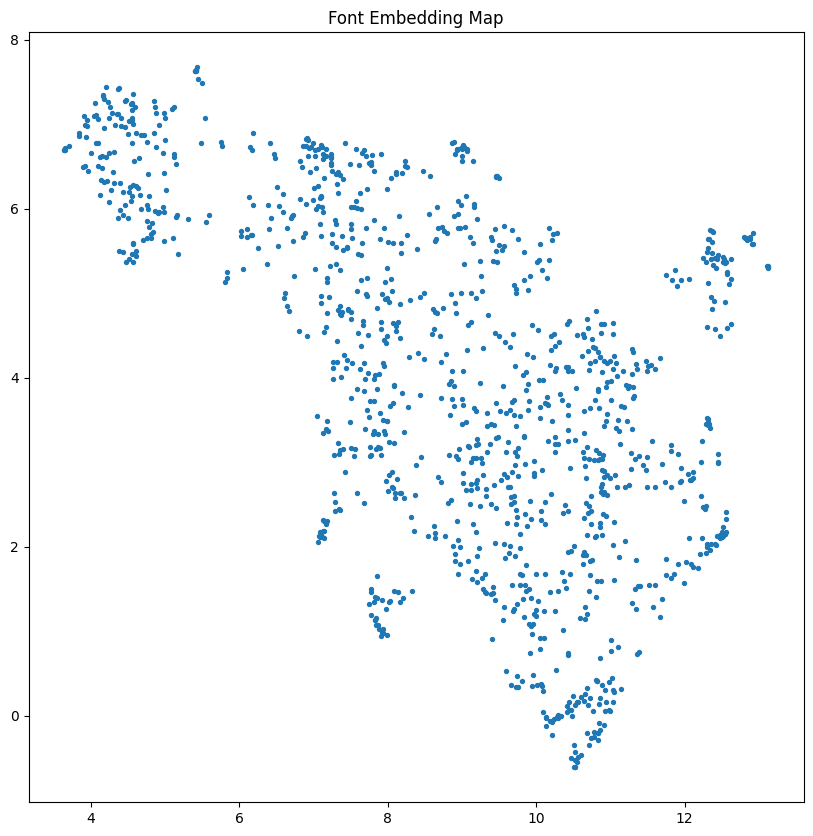

In [11]:
import umap
import matplotlib.pyplot as plt


# Using this to make our 2d embedding map
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine"
)

coords = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 10))
plt.scatter(coords[:, 0], coords[:, 1], s=8)
plt.title("Font Embedding Map")
plt.show()


In [12]:
import numpy as np
from math import ceil, sqrt

n = coords.shape[0]
grid_size = ceil(sqrt(n))

xs = np.linspace(coords[:,0].min(), coords[:,0].max(), grid_size)
ys = np.linspace(coords[:,1].min(), coords[:,1].max(), grid_size)

grid = np.array([
    (x, y)
    for y in ys
    for x in xs
])[:n]


In [13]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

cost = cdist(coords, grid)
row_ind, col_ind = linear_sum_assignment(cost)

grid_coords = grid[col_ind]

# After computing grid_coords = grid[col_ind]

# Compute integer grid positions
grid_size = ceil(sqrt(n))
integer_grid_coords = np.array([[idx // grid_size, idx % grid_size] for idx in col_ind])

# Save the integer Grid Coords instead
proj_dir = os.path.dirname(os.getcwd())  # Goes up one level to TheFontinator/
save_path = os.path.join(proj_dir, 'backend', 'data', 'IntGridCoords.npy')
np.save(save_path, integer_grid_coords)


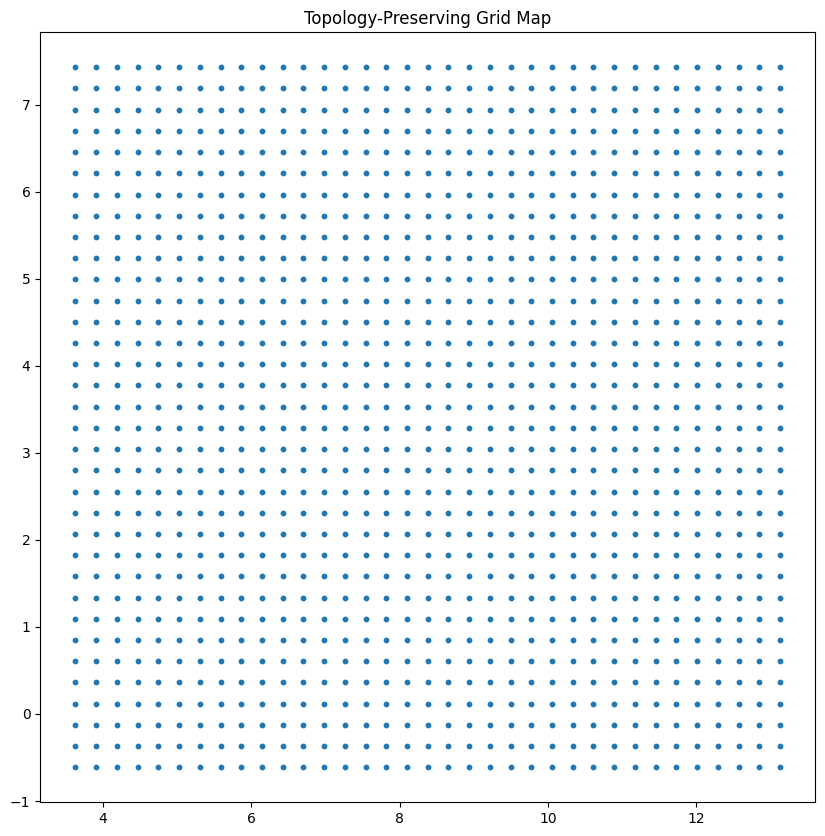

In [14]:
plt.figure(figsize=(10, 10))
plt.scatter(grid_coords[:, 0], grid_coords[:, 1], s=10)
plt.title("Topology-Preserving Grid Map")
plt.show()


In [57]:
# Grid Coords still match up in order of font_ids
integer_grid_coords

array([[20, 25],
       [ 8, 26],
       [20, 17],
       ...,
       [24,  3],
       [12,  5],
       [31, 28]], shape=(1190, 2))

In [67]:
for i in integer_grid_coords[:, 0]:
    if i == 17:
        print("17")

17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17
17


In [16]:
# Named font data because I'll probably expand this table to have metadata
# Converts to numpy for now
font_ids_np = np.array(font_ids)


# Save the Grid Coords and the id's for use in backend
save_path = os.path.join(proj_dir, 'backend', 'data', 'GridCoords.npy')
np.save(save_path, grid_coords)


# Named font data because I'll probably expand this table to have metadata
# Converts to numpy for now
save_path = os.path.join(proj_dir, 'backend', 'data', 'FontData.npy')
np.save(save_path, font_ids_np)

In [17]:
font_ids_np

array(['abeezee', 'abel', 'aboreto', ..., 'zeyada', 'zillaslab',
       'zillaslabhighlight'], shape=(1190,), dtype='<U28')

# Embedding Sliders

Sliders are based on Google's Expressive Tags

This way we have human labeled data to verify the zero shot training score accuracy

#### SLIDER V1
Before we get going we should test the accuracy of CLIP on the expressive labels made by humans in the google fonts dataset

In [35]:
classes = [
    'Active','Artistic','Awkward','Business','Calm','Childlike','Competent','Cute','Excited','Fancy',
    'Futuristic','Happy','Innovative','Loud','Playful','Rugged','Sincere','Sophisticated','Stiff','Vintage'
]

In [20]:
img_emb = embed_image("font-photos/alexbrush.png")

In [36]:
import pandas as pd
from sklearn.metrics import classification_report

image_dir = "font-photos"

results = []

classes_with_font = [f"{c} font" for c in classes]

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        image_path = os.path.join(image_dir, fname)
        image = Image.open(image_path).convert("RGB")
        inputs = processor(text=classes_with_font, images=image, return_tensors="pt", padding=True)
        outputs = model(**inputs)

        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1).detach().numpy()[0]

        font_name = fname.replace(".png", "")
        row = {"font": font_name.lower().replace(" ", "")}
        row.update({cls: prob for cls, prob in zip(classes, probs)})  # use original classes as keys
        results.append(row)

clip_df = pd.DataFrame(results)
clip_df.to_csv("tags/clip_predictions.csv", index=False)

100%|██████████| 1190/1190 [04:28<00:00,  4.43it/s]


In [37]:
clip_df.head()

,font,Active,Artistic,Awkward,Business,Calm,Childlike,Competent,Cute,Excited,...,Futuristic,Happy,Innovative,Loud,Playful,Rugged,Sincere,Sophisticated,Stiff,Vintage
0,abeezee,0.036308,0.045033,0.005897,0.091695,0.094607,0.024920,0.056401,0.068895,0.020027,...,0.013960,0.030402,0.035777,0.019155,0.179314,0.023067,0.028507,0.060660,0.019762,0.028002
1,abel,0.062266,0.045156,0.005318,0.100082,0.087041,0.015703,0.066969,0.079166,0.021956,...,0.009149,0.014005,0.019730,0.011821,0.161871,0.021372,0.030590,0.123798,0.011192,0.035700
2,aboreto,0.023381,0.032823,0.004406,0.136202,0.118760,0.013498,0.022584,0.074272,0.012458,...,0.009903,0.012019,0.033562,0.009114,0.126843,0.018250,0.021043,0.072155,0.018248,0.121985
3,abrilfatface,0.026435,0.056240,0.005357,0.114985,0.090276,0.020251,0.054612,0.057131,0.019897,...,0.009394,0.026666,0.028397,0.010274,0.149495,0.050047,0.017811,0.082454,0.039112,0.036068
4,acme,0.044313,0.064274,0.005497,0.105434,0.106508,0.026727,0.053854,0.066633,0.023163,...,0.013579,0.028128,0.034477,0.012938,0.155832,0.020272,0.024290,0.078197,0.023760,0.033569


In [38]:
ground_truth_df = pd.read_csv("tags/expressive_tags.csv")  # your existing labeled file
ground_truth_df["font"] = ground_truth_df["font"].str.lower().str.replace(" ", "", regex=False)

merged = pd.merge(clip_df, ground_truth_df, on="font", suffixes=("_clip", "_gt"))

In [48]:
# Classification report
tag_cols = classes

clip_preds = merged[[f"{t}_clip" for t in tag_cols]].values
gt_labels  = merged[[f"{t}_gt"  for t in tag_cols]].values

# Convert CLIP probs to binary using top 70th percentile threshold per font
# Need to use percentiles because all predictions were at or below ~0.5 (no strong predictions)
thresholds = np.percentile(clip_preds, 70, axis=1, keepdims=True)
clip_binary = (clip_preds >= thresholds).astype(int)
gt_binary   = (gt_labels  > 0).astype(int)

print(classification_report(gt_binary, clip_binary, target_names=tag_cols))

               precision    recall  f1-score   support

       Active       0.50      0.07      0.13       324
     Artistic       0.39      0.74      0.51       204
      Awkward       0.00      0.00      0.00       128
     Business       0.61      0.83      0.70       568
         Calm       0.30      0.93      0.45       290
    Childlike       0.09      0.09      0.09        91
    Competent       0.33      0.39      0.36       220
         Cute       0.17      0.83      0.29       159
      Excited       0.25      0.06      0.09       139
        Fancy       0.05      0.61      0.10        89
   Futuristic       0.71      0.06      0.12       263
        Happy       0.50      0.01      0.02       526
   Innovative       0.25      0.02      0.03       126
         Loud       1.00      0.02      0.03      1068
      Playful       0.21      0.96      0.34       231
       Rugged       0.14      0.09      0.11        86
      Sincere       0.24      0.03      0.06       281
Sophistic

c:\Users\windo\Desktop\TheFontinator\datawork\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

clip_preds = merged[[f"{t}_clip" for t in tag_cols]].values
gt_labels  = merged[[f"{t}_gt"  for t in tag_cols]].values

# Normalize ground truth to 0-1 if it isn't already
gt_normalized = gt_labels / gt_labels.max(axis=1, keepdims=True)

mae = mean_absolute_error(gt_normalized, clip_preds)
rmse = np.sqrt(mean_squared_error(gt_normalized, clip_preds))

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Per-tag breakdown
for i, tag in enumerate(tag_cols):
    tag_mae = mean_absolute_error(gt_normalized[:, i], clip_preds[:, i])
    print(f"{tag:<20} MAE: {tag_mae:.4f}")

MAE:  0.1771
RMSE: 0.3257
Active               MAE: 0.1099
Artistic             MAE: 0.1660
Awkward              MAE: 0.0839
Business             MAE: 0.2762
Calm                 MAE: 0.2841
Childlike            MAE: 0.0864
Competent            MAE: 0.1839
Cute                 MAE: 0.1177
Excited              MAE: 0.0898
Fancy                MAE: 0.1315
Futuristic           MAE: 0.1036
Happy                MAE: 0.1445
Innovative           MAE: 0.1216
Loud                 MAE: 0.4490
Playful              MAE: 0.2238
Rugged               MAE: 0.0762
Sincere              MAE: 0.2339
Sophisticated        MAE: 0.1028
Stiff                MAE: 0.2157
Vintage              MAE: 0.3414


### Initial Conclusion
Zero shot prediciton of fonts with CLIP fails to accurately represent the nature of a font

Will definetly need a model with finer tuning on font data

array([[<Axes: title={'center': 'Active'}>,
        <Axes: title={'center': 'Artistic'}>,
        <Axes: title={'center': 'Awkward'}>,
        <Axes: title={'center': 'Business'}>],
       [<Axes: title={'center': 'Calm'}>,
        <Axes: title={'center': 'Childlike'}>,
        <Axes: title={'center': 'Competent'}>,
        <Axes: title={'center': 'Cute'}>],
       [<Axes: title={'center': 'Excited'}>,
        <Axes: title={'center': 'Fancy'}>,
        <Axes: title={'center': 'Futuristic'}>,
        <Axes: title={'center': 'Happy'}>],
       [<Axes: title={'center': 'Innovative'}>,
        <Axes: title={'center': 'Loud'}>,
        <Axes: title={'center': 'Playful'}>,
        <Axes: title={'center': 'Rugged'}>],
       [<Axes: title={'center': 'Sincere'}>,
        <Axes: title={'center': 'Sophisticated'}>,
        <Axes: title={'center': 'Stiff'}>,
        <Axes: title={'center': 'Vintage'}>]], dtype=object)

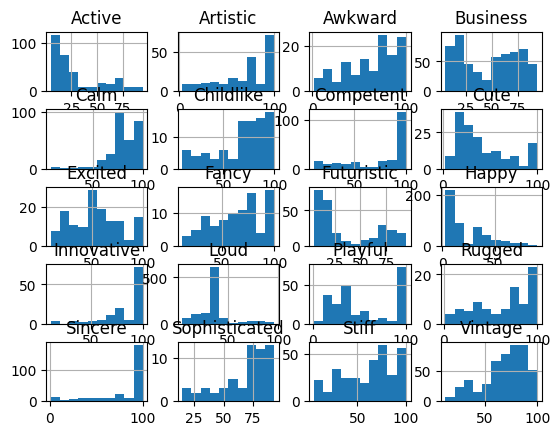

In [56]:
pd.DataFrame(gt_labels, columns=classes).replace(0, np.nan).hist()

array([[<Axes: title={'center': 'Active'}>,
        <Axes: title={'center': 'Artistic'}>,
        <Axes: title={'center': 'Awkward'}>,
        <Axes: title={'center': 'Business'}>],
       [<Axes: title={'center': 'Calm'}>,
        <Axes: title={'center': 'Childlike'}>,
        <Axes: title={'center': 'Competent'}>,
        <Axes: title={'center': 'Cute'}>],
       [<Axes: title={'center': 'Excited'}>,
        <Axes: title={'center': 'Fancy'}>,
        <Axes: title={'center': 'Futuristic'}>,
        <Axes: title={'center': 'Happy'}>],
       [<Axes: title={'center': 'Innovative'}>,
        <Axes: title={'center': 'Loud'}>,
        <Axes: title={'center': 'Playful'}>,
        <Axes: title={'center': 'Rugged'}>],
       [<Axes: title={'center': 'Sincere'}>,
        <Axes: title={'center': 'Sophisticated'}>,
        <Axes: title={'center': 'Stiff'}>,
        <Axes: title={'center': 'Vintage'}>]], dtype=object)

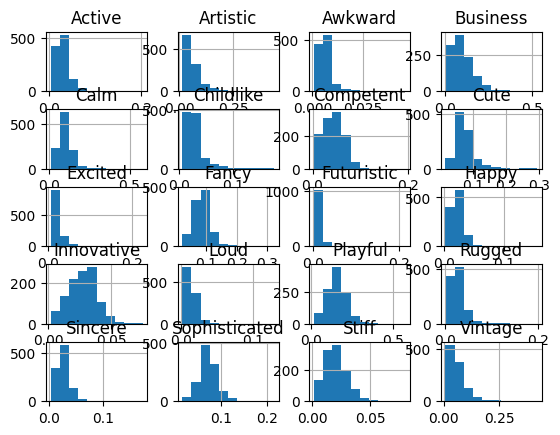

In [52]:
pd.DataFrame(clip_preds, columns=classes).replace(0, np.nan).hist()